In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
file_path = 'Data/train.csv'
df = pd.read_csv(file_path)
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [3]:
df.isnull().sum()

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [5]:
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  object 
 12  engi

In [7]:
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 58592 Columns: 44


In [8]:
df.duplicated().sum()

0

In [9]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [10]:
df["model"].value_counts()

model
M1     14948
M4     14018
M6     13776
M8      4173
M7      2940
M3      2373
M9      2114
M5      1598
M10     1209
M2      1080
M11      363
Name: count, dtype: int64

In [11]:
df["fuel_type"].value_counts()

fuel_type
Petrol    20532
CNG       20330
Diesel    17730
Name: count, dtype: int64

In [12]:
df["engine_type"].value_counts()

engine_type
F8D Petrol Engine            14948
1.5 L U2 CRDi                14018
K Series Dual jet            13776
K10C                          4173
1.2 L K Series Engine         2940
1.0 SCe                       2373
i-DTEC                        2114
1.5 Turbocharged Revotorq     1598
G12B                          1209
1.2 L K12N Dualjet            1080
1.5 Turbocharged Revotron      363
Name: count, dtype: int64

In [13]:
df["airbags"].value_counts()

airbags
2    40425
6    16958
1     1209
Name: count, dtype: int64

In [14]:
df["rear_brakes_type"].value_counts()

rear_brakes_type
Drum    44574
Disc    14018
Name: count, dtype: int64

In [15]:
df["cylinder"].value_counts()

cylinder
4    36735
3    21857
Name: count, dtype: int64

In [16]:
df["transmission_type"].value_counts()

transmission_type
Manual       38181
Automatic    20411
Name: count, dtype: int64

In [17]:
df["steering_type"].value_counts()

steering_type
Power       33502
Electric    23881
Manual       1209
Name: count, dtype: int64

In [18]:
df["gear_box"].value_counts()

gear_box
5    44211
6    14381
Name: count, dtype: int64

In [19]:
df["is_claim"].value_counts()

is_claim
0    54844
1     3748
Name: count, dtype: int64

In [20]:
df["max_power"].value_counts()

max_power
88.50bhp@6000rpm     17796
40.36bhp@6000rpm     14948
113.45bhp@4000rpm    14018
55.92bhp@5300rpm      4173
67.06bhp@5500rpm      2373
97.89bhp@3600rpm      2114
88.77bhp@4000rpm      1598
61.68bhp@6000rpm      1209
118.36bhp@5500rpm      363
Name: count, dtype: int64

In [21]:
df["max_torque"].value_counts()

max_torque
113Nm@4400rpm     17796
60Nm@3500rpm      14948
250Nm@2750rpm     14018
82.1Nm@3400rpm     4173
91Nm@4250rpm       2373
200Nm@1750rpm      2114
200Nm@3000rpm      1598
85Nm@3000rpm       1209
170Nm@4000rpm       363
Name: count, dtype: int64

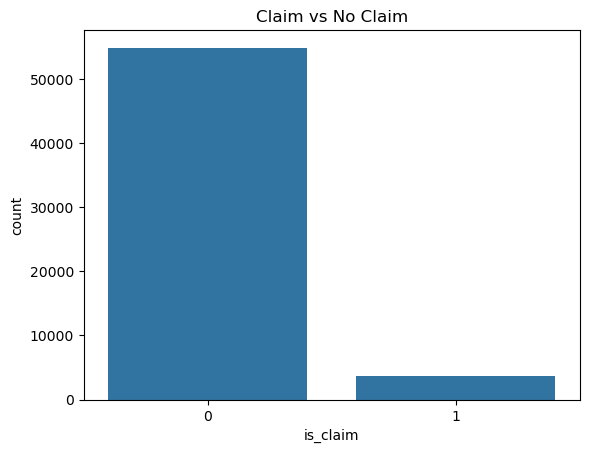

is_claim
0    0.936032
1    0.063968
Name: proportion, dtype: float64


In [22]:
sns.countplot(x='is_claim', data=df)
plt.title("Claim vs No Claim")
plt.show()

# Ratio
print(df['is_claim'].value_counts(normalize=True))


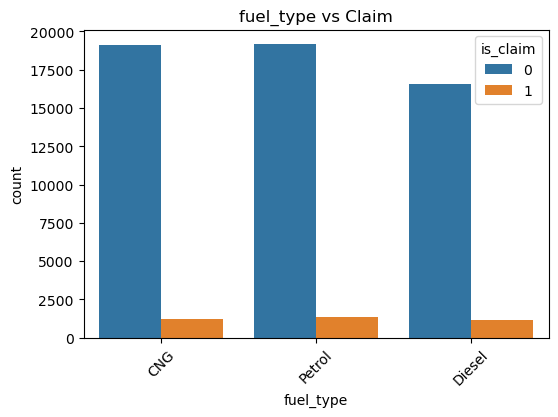

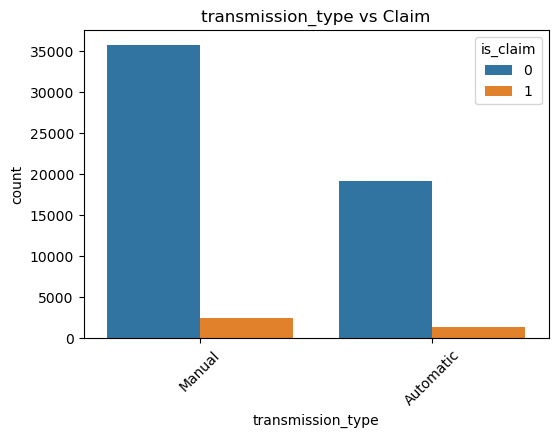

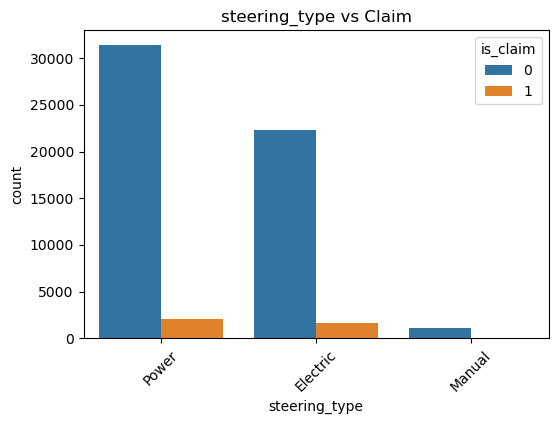

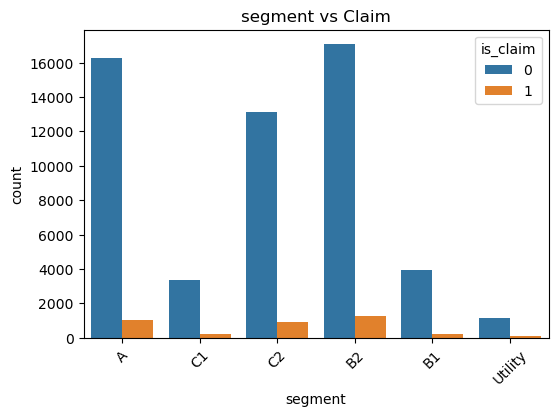

In [23]:
cat_cols = ['fuel_type','transmission_type','steering_type','segment']  # add yours

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='is_claim', data=df)
    plt.title(f"{col} vs Claim")
    plt.xticks(rotation=45)
    plt.show()


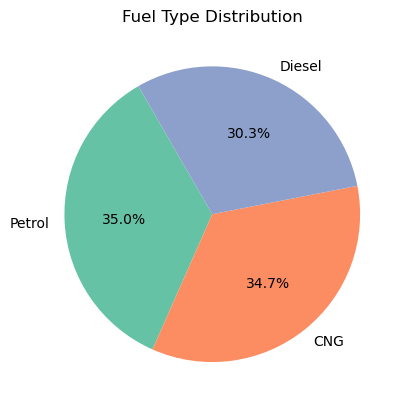

In [24]:
df['fuel_type'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2"),
    startangle=120
)
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()


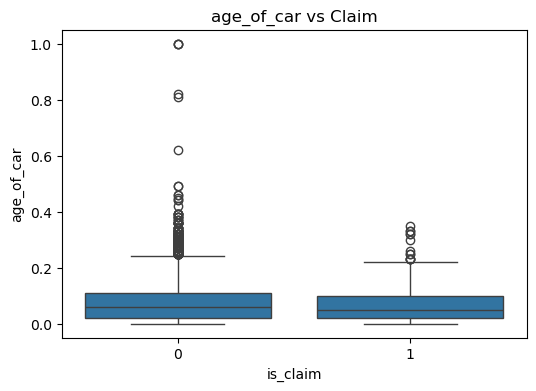

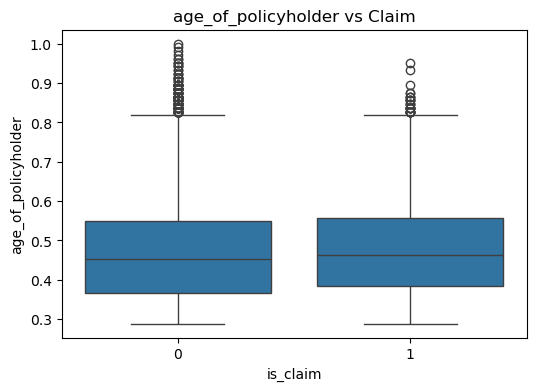

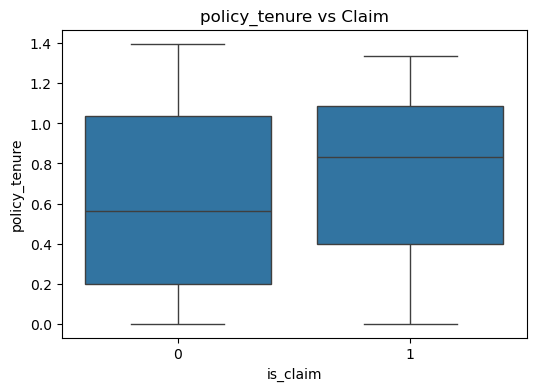

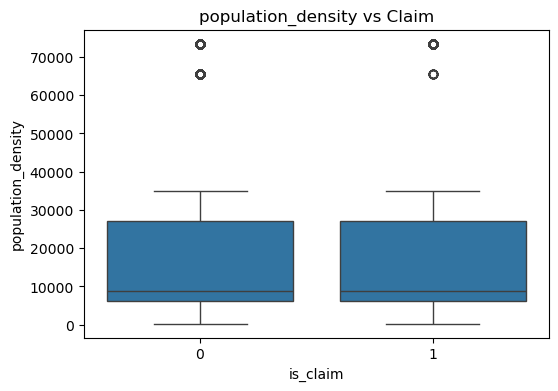

In [25]:
for col in ['age_of_car','age_of_policyholder','policy_tenure','population_density']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='is_claim', y=col, data=df)
    plt.title(f"{col} vs Claim")
    plt.show()


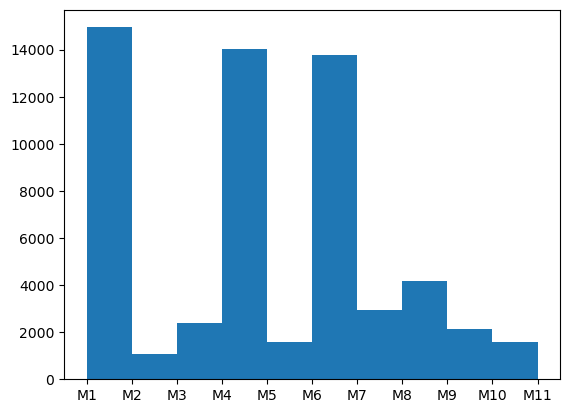

In [26]:
plt.hist(df['model'])
plt.show()

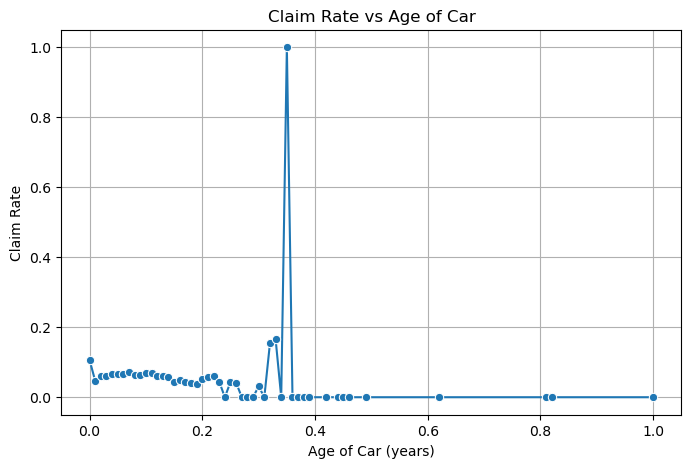

In [27]:
car_age_claim = df.groupby('age_of_car')['is_claim'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(x='age_of_car', y='is_claim', data=car_age_claim, marker='o')
plt.title("Claim Rate vs Age of Car")
plt.ylabel("Claim Rate")
plt.xlabel("Age of Car (years)")
plt.grid(True)
plt.show()


In [28]:
df['is_esc'] = df['is_esc'].map({'Yes': 1, 'No': 0})
df['is_adjustable_steering'] = df['is_adjustable_steering'].map({'Yes': 1, 'No': 0})
df['is_tpms'] = df['is_tpms'].map({'Yes': 1, 'No': 0})
df['is_parking_sensors'] = df['is_parking_sensors'].map({'Yes': 1, 'No': 0})
df['is_parking_camera'] = df['is_parking_camera'].map({'Yes': 1, 'No': 0})
df['is_front_fog_lights'] = df['is_front_fog_lights'].map({'Yes': 1, 'No': 0})
df['is_rear_window_wiper'] = df['is_rear_window_wiper'].map({'Yes': 1, 'No': 0})
df['is_rear_window_washer'] = df['is_rear_window_washer'].map({'Yes': 1, 'No': 0})
df['is_rear_window_defogger'] = df['is_rear_window_defogger'].map({'Yes': 1, 'No': 0})
df['is_brake_assist'] = df['is_brake_assist'].map({'Yes': 1, 'No': 0})
df['is_power_door_locks'] = df['is_power_door_locks'].map({'Yes': 1, 'No': 0})
df['is_central_locking'] = df['is_central_locking'].map({'Yes': 1, 'No': 0})
df['is_power_steering'] = df['is_power_steering'].map({'Yes': 1, 'No': 0})
df['is_driver_seat_height_adjustable'] = df['is_driver_seat_height_adjustable'].map({'Yes': 1, 'No': 0})
df['is_day_night_rear_view_mirror'] = df['is_day_night_rear_view_mirror'].map({'Yes': 1, 'No': 0})
df['is_ecw'] = df['is_ecw'].map({'Yes': 1, 'No': 0})
df['is_speed_alert'] = df['is_speed_alert'].map({'Yes': 1, 'No': 0})

In [29]:
binary_columns = [
    'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
    'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_central_locking', 'is_power_steering',
    'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
    'is_ecw', 'is_speed_alert'
]

for col in binary_columns:
    print(f"{col}: {df[col].unique()}")


is_esc: [0 1]
is_adjustable_steering: [0 1]
is_tpms: [0 1]
is_parking_sensors: [1 0]
is_parking_camera: [0 1]
is_front_fog_lights: [0 1]
is_rear_window_wiper: [0 1]
is_rear_window_washer: [0 1]
is_rear_window_defogger: [0 1]
is_brake_assist: [0 1]
is_power_door_locks: [0 1]
is_central_locking: [0 1]
is_power_steering: [1 0]
is_driver_seat_height_adjustable: [0 1]
is_day_night_rear_view_mirror: [0 1]
is_ecw: [0 1]
is_speed_alert: [1 0]


In [30]:
mapping = {1: "Yes", 0: "No"}   # reverse mapping

for col in binary_columns:
    print(f"Mapping for {col}:")
    print(mapping)
    print("-" * 40)


Mapping for is_esc:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_adjustable_steering:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_tpms:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_parking_sensors:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_parking_camera:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_front_fog_lights:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_rear_window_wiper:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_rear_window_washer:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_rear_window_defogger:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_brake_assist:
{1: 'Yes', 0: 'No'}
----------------------------------------
Mapping for is_power_door_locks:
{1: 'Yes', 0: 'No'}
-----------------------------

In [ ]:

cat_cols = ['area_cluster', 'segment', 'model', 'fuel_type','max_torque','engine_type','rear_brakes_type','transmission_type','steering_type','max_power']
encoders = {}
for col in cat_cols:
    df[col] = df[col].astype(str)  
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [32]:
for col, le in encoders.items():
    print(f"Mapping for {col}:")
    print(dict(zip(le.classes_, le.transform(le.classes_))))
    print("-"*40)


Mapping for area_cluster:
{'C1': 0, 'C10': 1, 'C11': 2, 'C12': 3, 'C13': 4, 'C14': 5, 'C15': 6, 'C16': 7, 'C17': 8, 'C18': 9, 'C19': 10, 'C2': 11, 'C20': 12, 'C21': 13, 'C22': 14, 'C3': 15, 'C4': 16, 'C5': 17, 'C6': 18, 'C7': 19, 'C8': 20, 'C9': 21}
----------------------------------------
Mapping for segment:
{'A': 0, 'B1': 1, 'B2': 2, 'C1': 3, 'C2': 4, 'Utility': 5}
----------------------------------------
Mapping for model:
{'M1': 0, 'M10': 1, 'M11': 2, 'M2': 3, 'M3': 4, 'M4': 5, 'M5': 6, 'M6': 7, 'M7': 8, 'M8': 9, 'M9': 10}
----------------------------------------
Mapping for fuel_type:
{'CNG': 0, 'Diesel': 1, 'Petrol': 2}
----------------------------------------
Mapping for max_torque:
{'113Nm@4400rpm': 0, '170Nm@4000rpm': 1, '200Nm@1750rpm': 2, '200Nm@3000rpm': 3, '250Nm@2750rpm': 4, '60Nm@3500rpm': 5, '82.1Nm@3400rpm': 6, '85Nm@3000rpm': 7, '91Nm@4250rpm': 8}
----------------------------------------
Mapping for engine_type:
{'1.0 SCe': 0, '1.2 L K Series Engine': 1, '1.2 L K12N 

In [33]:
df.head()

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,0,4990,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,ID00002,0.672619,0.02,0.375000,11,27003,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
2,ID00003,0.841110,0.02,0.384615,15,4076,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,ID00004,0.900277,0.11,0.432692,16,21622,1,3,3,2,...,1,1,1,1,1,1,1,1,2,0
4,ID00005,0.596403,0.11,0.634615,17,34738,2,0,4,2,...,0,1,1,1,0,1,1,1,2,0


In [119]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [120]:
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import numpy as np


# Extract numeric values from strings like "88.50bhp@6000rpm"
def extract_numeric(val):
    if isinstance(val, str):
        match = re.search(r"[-+]?\d*\.?\d+", val)
        return float(match.group()) if match else np.nan
    return val

for col in df.select_dtypes(exclude=["number"]).columns:
    df[col] = df[col].apply(extract_numeric)

# Fill any NaNs with mean
df = df.fillna(df.mean(numeric_only=True))

# ==============================================
#  Train-Test Split
# ==============================================
X = df.drop(columns=["is_claim","policy_id"])
y = df["is_claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean (claim rate):", y_train.mean().round(4))
print("y_test mean (claim rate):", y_test.mean().round(4))


 X_train shape: (46873, 42)
X_test shape: (11719, 42)
y_train mean (claim rate): 0.064
y_test mean (claim rate): 0.064


In [121]:
print("After cleaning:")
print(X.dtypes)
print("Any NaNs?", X.isna().sum().sum())


After cleaning:
policy_tenure                       float64
age_of_car                          float64
age_of_policyholder                 float64
area_cluster                          int32
population_density                    int64
make                                  int64
segment                               int32
model                                 int32
fuel_type                             int32
max_torque                            int32
max_power                             int32
engine_type                           int32
airbags                               int64
is_esc                                int64
is_adjustable_steering                int64
is_tpms                               int64
is_parking_sensors                    int64
is_parking_camera                     int64
rear_brakes_type                      int32
displacement                          int64
cylinder                              int64
transmission_type                     int32
gear_box        

In [122]:
X = X.fillna(X.mean())


In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Identify categorical & numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Pipelines
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])


In [124]:
df.isnull().sum()

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [125]:
# Logistic Regression
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# Decision Tree
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

# Evaluation function
def evaluate_model(y_test, y_pred, model_name):
    print(f"===== {model_name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")


===== Logistic Regression =====
Accuracy : 0.5642119634781124
Precision: 0.08000771158665895
Recall   : 0.5533333333333333
F1-score : 0.13980124642075123

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.56      0.71     10969
           1       0.08      0.55      0.14       750

    accuracy                           0.56     11719
   macro avg       0.51      0.56      0.42     11719
weighted avg       0.89      0.56      0.67     11719

===== Decision Tree =====
Accuracy : 0.8828398327502347
Precision: 0.0773405698778833
Recall   : 0.076
F1-score : 0.07666442501681238

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     10969
           1       0.08      0.08      0.08       750

    accuracy                           0.88     11719
   macro avg       0.51      0.51      0.51     11719
weighted avg       0.88      0.88      0.88     11719



In [126]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
from lightgbm import LGBMClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns


#  Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


# Random Forest Pipeline with SMOTE
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

# XGBoost Pipeline with SMOTE
xgb_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(
        n_estimators=200,
        eval_metric='logloss',
        random_state=42
    ))
])


# LightGBM Pipeline with SMOTE
lgbm_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(
        n_estimators=200,
        random_state=42,
        verbose=-1
    ))
])

# Train & Predict
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

# Evaluation Function
def evaluate_model(y_test, y_pred, model_name):
    print(f"===== {model_name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("-" * 60)

# Evaluate All Models
evaluate_model(y_test, y_pred_rf, "Random Forest with SMOTE")
evaluate_model(y_test, y_pred_xgb, "XGBoost with SMOTE")
evaluate_model(y_test, y_pred_lgbm, "LightGBM with SMOTE")


===== Random Forest with SMOTE =====
Accuracy : 0.8817305230821743
Precision: 0.08914728682170543
Recall   : 0.092
F1-score : 0.09055118110236221

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94     10969
           1       0.09      0.09      0.09       750

    accuracy                           0.88     11719
   macro avg       0.51      0.51      0.51     11719
weighted avg       0.88      0.88      0.88     11719

------------------------------------------------------------
===== XGBoost with SMOTE =====
Accuracy : 0.9236282959296869
Precision: 0.1164021164021164
Recall   : 0.029333333333333333
F1-score : 0.046858359957401494

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96     10969
           1       0.12      0.03      0.05       750

    accuracy                           0.92     11719
   macro avg       0.53      0.51      0.50

In [127]:
results = []

for name, y_pred in [
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb),
    ("LightGBM", y_pred_lgbm)
]:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print("\n===== Model Comparison =====")
print(results_df.sort_values(by="F1", ascending=False).to_string(index=False))



===== Model Comparison =====
        Model  Accuracy  Precision   Recall       F1
Random Forest  0.881731   0.089147 0.092000 0.090551
      XGBoost  0.923628   0.116402 0.029333 0.046858
     LightGBM  0.932161   0.075472 0.005333 0.009963


In [128]:
print(X.columns)


Index(['policy_tenure', 'age_of_car', 'age_of_policyholder', 'area_cluster',
       'population_density', 'make', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating'],
      dtype='object')


In [129]:
# HYPERPARAMETER TUNING & FEATURE ENGINEERING
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# parameter grids
rf_params = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

xgb_params = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__max_depth': [3, 5, 7],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

lgbm_params = {
    'lgbm__n_estimators': [100, 200, 300],
    'lgbm__learning_rate': [0.01, 0.05, 0.1],
    'lgbm__num_leaves': [31, 63, 127],
    'lgbm__max_depth': [-1, 10, 20],
    'lgbm__subsample': [0.8, 1.0],
    'lgbm__colsample_bytree': [0.8, 1.0]
}

# Build pipelines
rf_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

xgb_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

lgbm_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1))
])

# Randomized Search for each model
models = {
    'Random Forest': (rf_pipe, rf_params),
    'XGBoost': (xgb_pipe, xgb_params),
    'LightGBM': (lgbm_pipe, lgbm_params)
}

results = {}

for name, (pipe, params) in models.items():
    print(f"\n Tuning {name} ...")
    search = RandomizedSearchCV(
        pipe, params, n_iter=5, cv=3, scoring='f1', verbose=1, random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'best_params': search.best_params_,
        'f1_score': f1,
        'report': classification_report(y_test, y_pred, output_dict=False)
    }

# Display Tuning Results

print("***** Hyperparameter Tuning Results *****")

for name, info in results.items():
    print(f"\n{name}")
    print(f"Best Params: {info['best_params']}")
    print(f"F1-Score: {info['f1_score']:.4f}")
    print(info['report'])


# Feature Importance from Best Model

best_model_name = max(results, key=lambda x: results[x]['f1_score'])
print(f"\n---> Best model after tuning: {best_model_name}")

# Extract feature importances if supported
best_pipeline = results[best_model_name]
model = models[best_model_name][0].named_steps[
    list(models[best_model_name][0].named_steps.keys())[-1]
]

if hasattr(model, 'feature_importances_'):
    # Get feature names
    cat_features = list(models[best_model_name][0]
                        .named_steps['preprocessor']
                        .transformers_[1][1]
                        .get_feature_names_out(categorical_cols))
    all_features = list(numeric_cols) + cat_features
    importances = pd.DataFrame({
        'Feature': all_features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    print("\nTop 10 Important Features:")
    display(importances.head(10))
else:
    print("\nFeature importance not available for this model.")



 Tuning Random Forest ...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

 Tuning XGBoost ...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

 Tuning LightGBM ...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
***** Hyperparameter Tuning Results *****

Random Forest
Best Params: {'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 1, 'rf__max_depth': 20}
F1-Score: 0.1355
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     10969
           1       0.09      0.25      0.14       750

    accuracy                           0.79     11719
   macro avg       0.52      0.54      0.51     11719
weighted avg       0.89      0.79      0.83     11719


XGBoost
Best Params: {'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 1.0}
F1-Score: 0.1714
              precision    recall  f1-score   support

          

In [130]:
for name, info in results.items():
    print(f"\n🔹 Model: {name}")
    print(f"Best Parameters:")
    for k, v in info['best_params'].items():
        print(f"   {k}: {v}")
    print(f"\nF1-Score: {info['f1_score']:.4f}")
    
    # Convert report to DataFrame for better readability
    report_df = pd.DataFrame.from_dict(
        classification_report(y_test, models[name][0].fit(X_train, y_train).predict(X_test), output_dict=True)
    ).transpose()
    
    print("\nClassification Report:")
    display(report_df)
    print("-" * 80)



🔹 Model: Random Forest
Best Parameters:
   rf__n_estimators: 300
   rf__min_samples_split: 10
   rf__min_samples_leaf: 1
   rf__max_depth: 20

F1-Score: 0.1355

Classification Report:


,precision,recall,f1-score,support
0,0.937300,0.936275,0.936787,10969.000000
1,0.082677,0.084000,0.083333,750.000000
accuracy,0.881731,0.881731,0.881731,0.881731
macro avg,0.509989,0.510137,0.510060,11719.000000
weighted avg,0.882606,0.881731,0.882167,11719.000000


--------------------------------------------------------------------------------

🔹 Model: XGBoost
Best Parameters:
   xgb__subsample: 0.8
   xgb__n_estimators: 200
   xgb__max_depth: 5
   xgb__learning_rate: 0.01
   xgb__colsample_bytree: 1.0

F1-Score: 0.1714

Classification Report:


,precision,recall,f1-score,support
0,0.937093,0.984593,0.960256,10969.000000
1,0.128866,0.033333,0.052966,750.000000
accuracy,0.923714,0.923714,0.923714,0.923714
macro avg,0.532980,0.508963,0.506611,11719.000000
weighted avg,0.885368,0.923714,0.902191,11719.000000


--------------------------------------------------------------------------------

🔹 Model: LightGBM
Best Parameters:
   lgbm__subsample: 0.8
   lgbm__num_leaves: 31
   lgbm__n_estimators: 100
   lgbm__max_depth: 10
   lgbm__learning_rate: 0.01
   lgbm__colsample_bytree: 1.0

F1-Score: 0.1609

Classification Report:


,precision,recall,f1-score,support
0,0.936382,0.992980,0.963851,10969.000000
1,0.114943,0.013333,0.023895,750.000000
accuracy,0.930284,0.930284,0.930284,0.930284
macro avg,0.525662,0.503157,0.493873,11719.000000
weighted avg,0.883811,0.930284,0.903695,11719.000000


--------------------------------------------------------------------------------


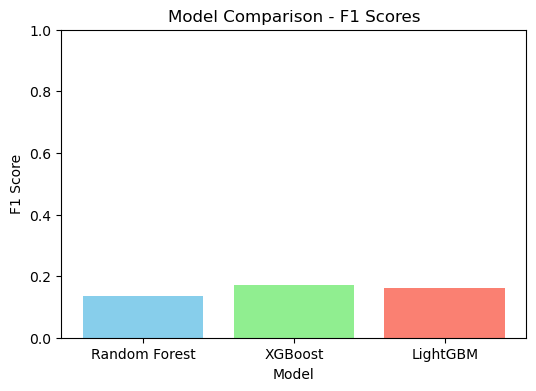

In [131]:
# DataFrame of scores
score_df = pd.DataFrame({
    'Model': list(results.keys()),
    'F1 Score': [info['f1_score'] for info in results.values()]
})

plt.figure(figsize=(6,4))
plt.bar(score_df['Model'], score_df['F1 Score'], color=['skyblue','lightgreen','salmon'])
plt.title("Model Comparison - F1 Scores")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()



🏆 Best Model Selected: XGBoost
✅ Pipeline is already fitted.


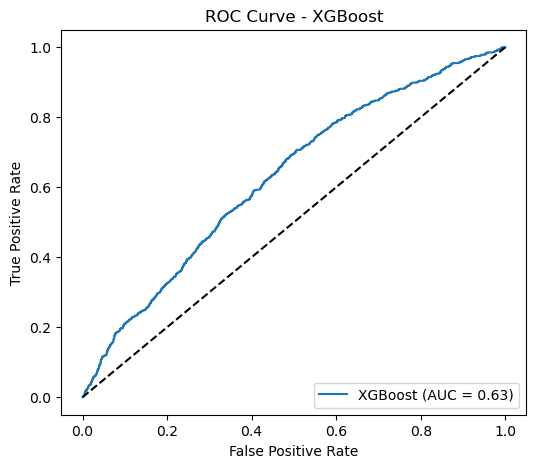


🔝 Top 10 Most Predictive Features:


,Feature,Importance
20,cylinder,0.199757
1,age_of_car,0.178489
2,age_of_policyholder,0.077039
4,population_density,0.056144
3,area_cluster,0.048482
7,model,0.044955
28,gross_weight,0.034215
0,policy_tenure,0.030947
19,displacement,0.026935
32,is_rear_window_defogger,0.025441


C:\Users\shree\AppData\Local\Temp\ipykernel_17488\3106993388.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')


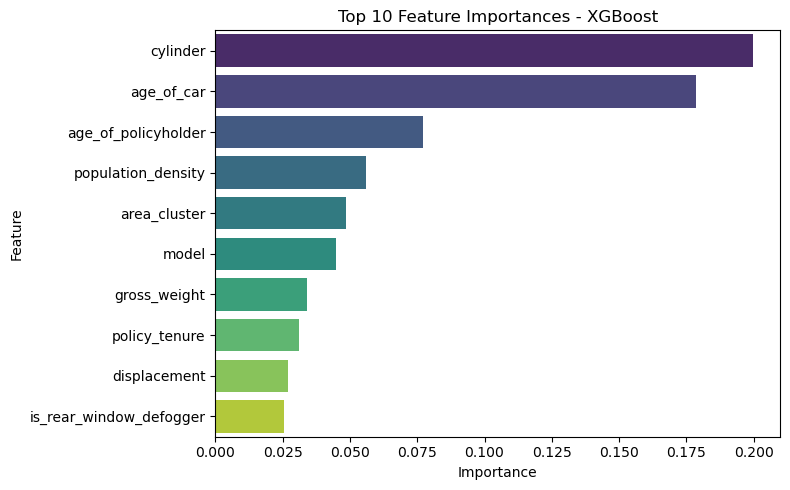


💡 Business Insights & Model Summary:
- Best model after tuning: **XGBoost** with F1-score: 0.1714
- ROC-AUC Score: 0.6280
- Top predictive features above can guide domain teams to focus on key drivers influencing the target variable.
- Consider using SHAP for deeper interpretability if stakeholders require explainability.


In [132]:
# ==========================================
# 🧩 RESULTS CONSOLIDATION & INSIGHTS 
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.exceptions import NotFittedError
import pandas as pd
import numpy as np

# Identify Best Model
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_pipeline = models[best_model_name][0]
print(f"\n🏆 Best Model Selected: {best_model_name}")

# Ensure pipeline is fitted
try:
    _ = best_pipeline.predict(X_test[:5])
    print("✅ Pipeline is already fitted.")
except NotFittedError:
    print("⚙️ Refitting best_pipeline on training data...")
    best_pipeline.fit(X_train, y_train)
    print("✅ Pipeline successfully fitted.")

# Predictions
y_pred = best_pipeline.predict(X_test)
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc='lower right')
plt.show()

# ---------------------------------------------------
# Feature Importance (works only for tree models)
# ---------------------------------------------------
model_step_name = list(best_pipeline.named_steps.keys())[-1]
model = best_pipeline.named_steps[model_step_name]

if hasattr(model, 'feature_importances_'):
    preprocessor = best_pipeline.named_steps['preprocessor']

    # Safely generate transformed feature names from pipeline output
    try:
        X_transformed = preprocessor.transform(X_train.head(1))
    except NotFittedError:
        print("⚙️ Fitting preprocessor since it wasn't directly fitted...")
        preprocessor.fit(X_train)
        X_transformed = preprocessor.transform(X_train.head(1))

    # Use feature names from fitted preprocessor (safe even if OneHotEncoder was inside ColumnTransformer)
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue
        if hasattr(transformer, 'get_feature_names_out'):
            try:
                names = transformer.get_feature_names_out(cols)
            except Exception:
                names = cols
        else:
            names = cols
        feature_names.extend(names)

    # Ensure the lengths match
    n_feats = len(model.feature_importances_)
    feature_names = feature_names[:n_feats]

    importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': model.feature_importances_[:len(feature_names)]
    }).sort_values(by='Importance', ascending=False)

    print("\n🔝 Top 10 Most Predictive Features:")
    display(importances.head(10))

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importance', y='Feature', data=importances.head(10), palette='viridis')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️ {best_model_name} does not provide feature_importances_ directly.")

# ---------------------------------------------------
# Business Insights
# ---------------------------------------------------
print("\n💡 Business Insights & Model Summary:")
print(f"- Best model after tuning: **{best_model_name}** with F1-score: {results[best_model_name]['f1_score']:.4f}")
print(f"- ROC-AUC Score: {roc_auc:.4f}")
print("- Top predictive features above can guide domain teams to focus on key drivers influencing the target variable.")
print("- Consider using SHAP for deeper interpretability if stakeholders require explainability.")


In [ ]:
import joblib

joblib.dump(best_pipeline, "Joblib/TrainedModel.joblib")
print("✅ Pipeline saved successfully as 'TrainedModel.joblib'")

✅ Pipeline saved successfully as 'TrainedModel.joblib'


In [ ]:
import pickle

with open("Joblib/TrainedModel.joblib", "rb") as f:
    model = pickle.load(f)

print("Loaded object type:", type(model))


Loaded object type: <class 'numpy.ndarray'>


In [ ]:
import joblib
model = joblib.load("Joblib/TrainedModel.joblib")

print("Loaded object type:", type(model))
print("Pipeline steps:", model.named_steps.keys())


Loaded object type: <class 'imblearn.pipeline.Pipeline'>
Pipeline steps: dict_keys(['preprocessor', 'smote', 'xgb'])


In [ ]:
model = joblib.load("Joblib/TrainedModel.joblib")
print(model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['policy_tenure', 'age_of_car', 'age_of_policyholder', 'area_cluster',
       'population_density', 'make', 'segment', 'model', 'fuel_type',
       'max_torque', 'max_power', 'engine_type', 'airbags', 'is_esc',
       'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camer...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, 